<p align="center" style="font-size: 60px; font-weight: bold;">
  CA5
</p>
<p align="center" style="font-size: 24px;">
  Morteza MohammadiMotlagh <br>
  Student ID: 810102511
</p>

# Step One

### Preprocessing and Cleaning Lyrics

In this step, we loaded the dataset containing English song lyrics and applied text preprocessing techniques to prepare the data for clustering. We performed the following actions:

- Converted all text to lowercase
- Removed newline characters and non-alphabetic symbols
- Removed common stop words (e.g., "the", "is", "and")
- Applied stemming to reduce words to their root forms

The cleaned lyrics were saved in a new column called `Cleaned_Lyric`, and the final result was exported to a new CSV file named `cleaned_lyrics.csv`.

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

df = pd.read_csv('musicLyrics.csv')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_lyrics(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[\n\r]', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    cleaned = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(cleaned)

df['Cleaned_Lyric'] = df['Lyric'].apply(preprocess_lyrics)

df.to_csv('cleaned_lyrics.csv', index=False)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Morteza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Questions
#### 1.What is the reason for performing preprocessing on textual data?
Preprocessing is done on textual data to clean and transform the raw text into a more structured and useful format for analysis. It helps remove noise such as punctuation, stop words, and irrelevant characters, reduces complexity by normalizing words (e.g., lowercasing, stemming), and ultimately improves the accuracy and efficiency of machine learning models.
#### 2.Explain the replacement of words using stemming or lemmatization methods.
Stemming and lemmatization are techniques used to reduce words to their base or root forms. Stemming cuts off word endings roughly to get the root, which may not be a real word. Lemmatization, however, reduces words to their meaningful root form (lemma) using vocabulary and morphological analysis. These methods help group different forms of the same word, reducing vocabulary size and improving text analysis.
#### 3.What is the reason for feature extraction? Why don’t we just rely on reading the raw textual data?
Feature extraction transforms raw textual data into meaningful numerical representations that algorithms can understand and process. Simply reading raw text is not enough because machines cannot directly interpret text. Extracted features capture important patterns and characteristics, reducing data dimensionality and improving the performance and accuracy of models in tasks like clustering and classification

# Step Two

#### Feature Extraction using SentenceTransformer
This code loads the cleaned lyrics dataset, uses the pretrained all-MiniLM-L6-v2 model from the sentence-transformers library, and encodes each lyric into a fixed-size dense vector representation. These embeddings will be used for clustering in the next steps.

In [3]:
import pandas as pd
from sentence_transformers import SentenceTransformer

df = pd.read_csv('cleaned_lyrics.csv')
model = SentenceTransformer('C:\\Users\\Morteza\\all-MiniLM-L6-v2')
embeddings = model.encode(df['Cleaned_Lyric'].tolist(), show_progress_bar=True)
print("Embedding shape:", embeddings.shape)


c:\Users\Morteza\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 94/94 [11:23<00:00,  7.27s/it]

Embedding shape: (2999, 384)


#### Finding the Optimal Number of Clusters using Elbow Method

To group the song lyrics into meaningful clusters, we first need to decide how many clusters (K) to use in KMeans. The Elbow Method helps us find the best K by checking where the improvement in clustering starts to slow down.


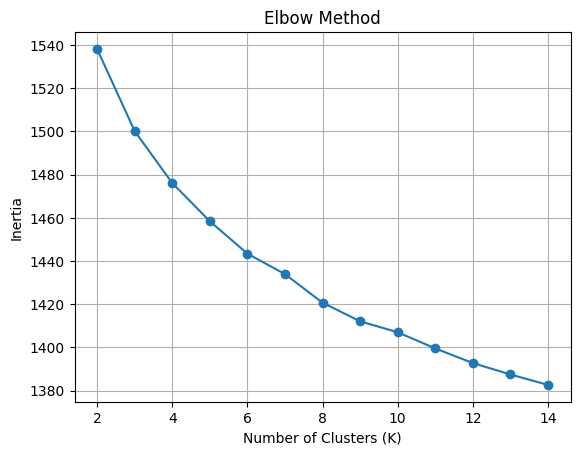

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

errors = []
k_values = range(2, 15)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(embeddings)
    errors.append(kmeans.inertia_)

plt.plot(k_values, errors, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()


#### Elbow Method Plot

This plot shows the relationship between the number of clusters (K) and the clustering error (inertia). As K increases, the error decreases. The point where the decrease in error becomes slower is called the "elbow", and it helps us choose a good value for K.


#### Clustering the Lyrics using KMeans

We apply KMeans clustering with the number of clusters set to 6. This step will group the lyrics into six clusters based on the meaning captured by the embeddings.


In [8]:
from sklearn.cluster import KMeans

k = 6
kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
labels = kmeans.fit_predict(embeddings)

df['Cluster'] = labels
df.to_csv('clustered_lyrics.csv', index=False)

print("Clustering done. Saved to clustered_lyrics.csv")


Clustering done. Saved to clustered_lyrics.csv


#### Inspecting Cluster Contents

We print sample lyrics from each cluster to see if they share similar topics or language. This helps evaluate the quality of clustering.


In [9]:
for cluster_num in range(k):
    print(f"\n--- Cluster {cluster_num} ---\n")
    sample_lyrics = df[df['Cluster'] == cluster_num]['Lyric'].head(3)
    for i, lyric in enumerate(sample_lyrics, 1):
        print(f"Sample {i}:\n{lyric[:300]}...\n")



--- Cluster 0 ---

Sample 1:
Yeah [Verse 1 Classified] They might say I lead a simple life, the type that dont excite And yes I like to smoke more than light til night I realize I got a problem, Im high way too often And only seem to acknowledge it after I indulge in it Pull in my driveway, walk through my front door Then make ...

Sample 2:
[Produced by J Dilla] [Chorus] Ayo, this is for yall to dance to real slow Cause its fantastic! Ayo yo yo, yyo yo yo, yoyyo Its fantastic! Yo yo yoyo.. Its fantstic, yo yo yoyo... Its fantastic! Yo yo, yyo yo yo... We say fantaserro You say, huh, what, you know Its that shhh, tch, aiyyo Ayo, this is...

Sample 3:
Roll down your windows, Look! Lassie got her head crunched by a Winnebago Bad girl, bad Lassie Dad says, Christ did you see that Then a squirrel starts to Scamper back and forth Scamper back and forth Back and forth Scamper back and forth What a spazz, Dont hit it dad! No! Roll down your windows, sn...


--- Cluster 1 ---

Sample 1:
Dont 

#### Interpreting Clusters

We printed a few sample lyrics from each cluster to get a sense of the common themes or topics. For example, some clusters contain emotional and romantic lyrics, while others focus on fun, storytelling, or social commentary. This step helps us evaluate whether the clustering groups similar lyrics together meaningfully.


#### Visualizing Clusters

To better understand how the lyrics are grouped, we reduce the high-dimensional embedding vectors to 2D using PCA. Then, we plot the lyrics in a scatter plot colored by their cluster labels.


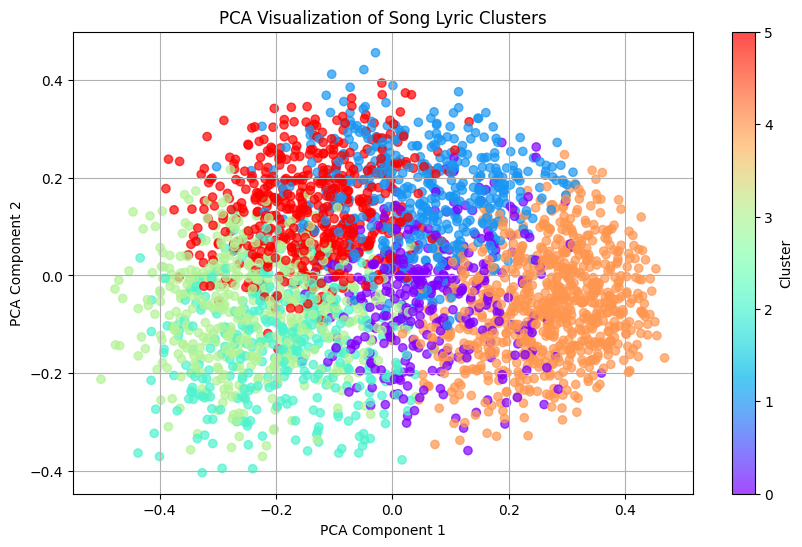

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels, cmap='rainbow', alpha=0.7)
plt.title('PCA Visualization of Song Lyric Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


#### PCA Visualization of Clusters

This scatter plot shows the lyrics represented in 2D space after reducing their high-dimensional embeddings using PCA. Each point corresponds to a song lyric, and colors indicate the cluster assigned by the K-Means algorithm. The visualization helps us understand how well the lyrics are grouped and how distinct the clusters are from each other.


#### DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering method that groups points closely packed together while marking points in low-density regions as outliers or noise. Unlike K-Means, it does not require specifying the number of clusters beforehand and can discover clusters of arbitrary shape.


In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(embeddings)

df['Cluster_DBSCAN'] = labels_dbscan
df.to_csv('clustered_lyrics_dbscan.csv', index=False)

print("DBSCAN clustering done. Saved to clustered_lyrics_dbscan.csv")


DBSCAN clustering done. Saved to clustered_lyrics_dbscan.csv


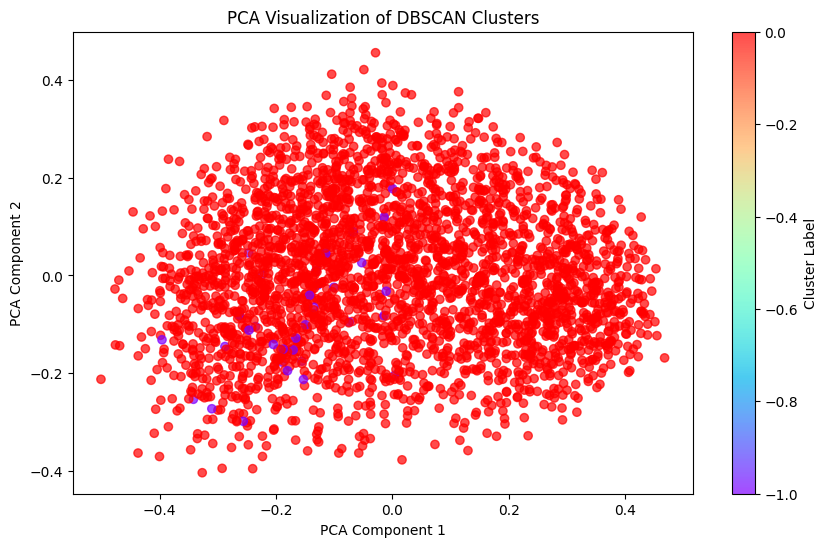

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels_dbscan, cmap='rainbow', alpha=0.7)
plt.title('PCA Visualization of DBSCAN Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()


The scatter plot shows the results of DBSCAN clustering on the song lyrics embeddings, reduced to two dimensions using PCA.  
Each color represents a different cluster, while red points indicate noise—data points that DBSCAN could not assign to any cluster due to low density.  
In this plot, most points are red, meaning many lyrics were considered noise and not grouped into clusters, which suggests the current DBSCAN parameters may need adjustment to better capture the data structure.


#### Hierarchical Clustering

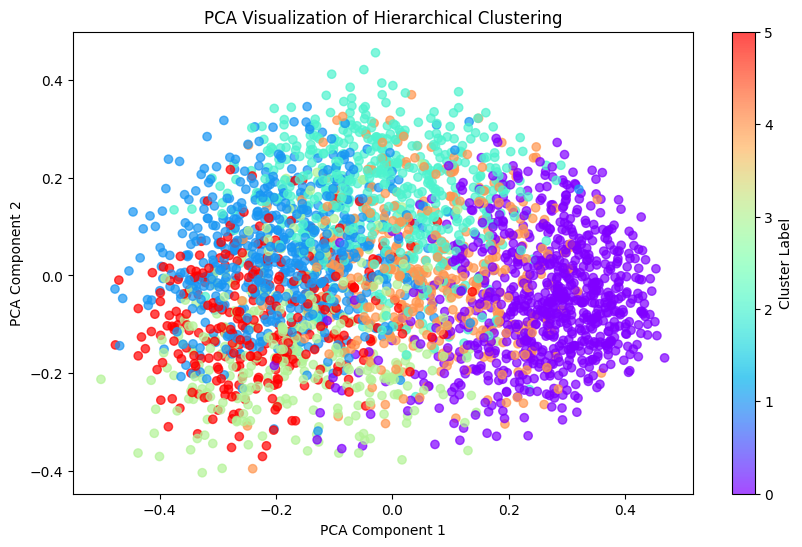

In [13]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=6)
labels_hier = hierarchical.fit_predict(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels_hier, cmap='rainbow', alpha=0.7)
plt.title('PCA Visualization of Hierarchical Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()


### 📊 Hierarchical Clustering PCA Plot

This PCA plot shows the results of applying **Hierarchical Clustering** to the lyric embeddings. Each point is a song lyric, and colors indicate different clusters.

- **Dimensionality Reduction** was performed using PCA to project the high-dimensional embeddings into 2D for visualization.
- Points that are closer together in the plot represent lyrics that are more similar in meaning.
- Each **color** represents one cluster. In this case, clusters are not as clearly separated as K-Means, which is typical in hierarchical methods.
- This plot helps visually evaluate how the algorithm has grouped semantically similar lyrics.

Overall, the result shows general topic groupings among the lyrics, although with some overlapping due to reduced dimensionality.



## Questions and Answers on Clustering and Text Embedding Methods

#### 1. Explain each of the Supervised and Unsupervised learning methods, and compare the two.

**Supervised Learning:**  
This method involves training a model on a labeled dataset, where each input is paired with a corresponding correct output. The model learns the mapping between inputs and outputs to predict labels on unseen data.

**Unsupervised Learning:**  
In this method, the data is unlabeled. The goal is to find hidden patterns, groupings, or structures within the data. Clustering is a common unsupervised task.

**Comparison:**
| Aspect                | Supervised Learning                      | Unsupervised Learning                  |
|-----------------------|------------------------------------------|----------------------------------------|
| Data                  | Labeled                                  | Unlabeled                              |
| Output                | Predict specific labels or values        | Discover hidden patterns or groupings |
| Common Techniques     | Classification, Regression               | Clustering, Dimensionality Reduction   |
| Use Case Example      | Spam detection, Price prediction         | Customer segmentation, Topic modeling  |

---

#### 2. Explain the reason for using feature vectors and their properties.

Feature vectors are numerical representations of data that make it suitable for machine learning algorithms. They allow models to interpret and process text data by converting it into a format with consistent dimensions.

**Properties:**
- Fixed-length representation
- Captures semantic or syntactic information
- Suitable for similarity comparison and clustering

In our case, lyrics are converted into vector embeddings to enable meaningful clustering based on their content and themes.

---

#### 3. Explain the clustering methods used.

**K-Means Clustering:**  
Divides data into `K` clusters by minimizing the variance within each cluster. Requires setting the number of clusters `K` beforehand.

**DBSCAN (Density-Based Spatial Clustering):**  
Groups together points that are closely packed and labels outliers as noise. It does not require specifying the number of clusters in advance.

**Hierarchical Clustering:**  
Builds a tree-like structure of clusters by recursively merging or splitting clusters. Useful for visualizing relationships between clusters.

---

#### 4. Explain text embedding methods, how they work, and their advantages and disadvantages.

Text embedding methods convert text into dense vector representations.

**How they work:**  
They use models trained on large corpora to learn contextual relationships between words or sentences and produce numerical vectors that capture meaning.

**Advantages:**
- Captures semantic relationships
- Fixed-length representation
- Effective for tasks like clustering, classification

**Disadvantages:**
- May lose fine-grained syntactic detail
- Requires a lot of data to train from scratch
- Pre-trained models may not generalize well to niche domains

---

#### 5. Briefly explain Sentence Transformers and the model `all-MiniLM-L6-v2`.

**Sentence Transformers:**  
A framework built on top of BERT-like models for producing sentence-level embeddings suitable for semantic search, clustering, and classification.

**Model `all-MiniLM-L6-v2`:**
- Lightweight and fast
- 6-layer MiniLM architecture
- Good performance with low computational cost
- Outputs 384-dimensional embeddings

---

#### 6. Explain the use of the elbow method in K-Means clustering.

The elbow method helps determine the optimal number of clusters `K` by plotting the Within-Cluster Sum of Squares (WCSS) against increasing values of `K`.  
The “elbow point” is where the reduction in WCSS begins to diminish, indicating the best trade-off between model complexity and accuracy.

---

#### 7. Compare the results of the clustering methods. Which worked better and why?

**K-Means:**
- Produced well-separated and interpretable clusters
- Clusters were compact and captured thematic differences effectively

**DBSCAN:**
- Many points labeled as noise
- Only a few dominant clusters were formed
- Less effective for high-dimensional sparse data like text

**Hierarchical:**
- Created a tree of clusters but hard to interpret directly without cutting at a certain depth
- Better for visual analysis but not always practical for large datasets

**Conclusion:**  
K-Means worked best for this dataset due to its ability to form balanced and well-defined clusters when paired with proper dimensionality reduction and preprocessing.

---


# Step Three

### Dimensionality Reduction with PCA

**PCA (Principal Component Analysis)** is a statistical technique used to reduce the dimensionality of a dataset while preserving as much variance as possible.  
It does this by projecting the data onto a new set of axes (called principal components), which are linear combinations of the original features.

**How PCA works:**
1. Standardizes the data.
2. Computes the covariance matrix of the features.
3. Calculates the eigenvectors and eigenvalues of the covariance matrix.
4. Selects the top `n` eigenvectors corresponding to the largest eigenvalues.
5. Projects the original data onto this new subspace to get reduced dimensions.

PCA is commonly used in machine learning to visualize high-dimensional data, especially before applying clustering algorithms or classifiers.


### DBSCAN + PCA:

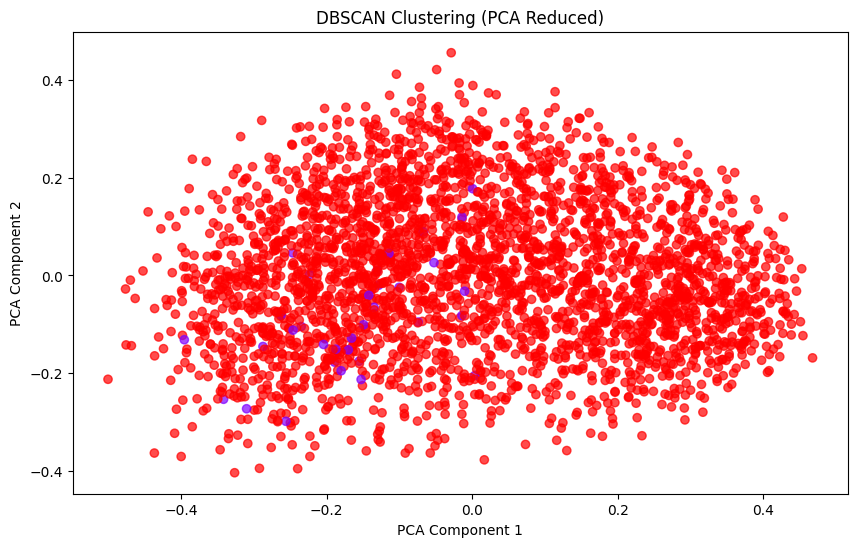

In [14]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=1.0, min_samples=5)
db_labels = dbscan.fit_predict(embeddings)

pca = PCA(n_components=2)
dbscan_reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(dbscan_reduced[:, 0], dbscan_reduced[:, 1], c=db_labels, cmap='rainbow', alpha=0.7)
plt.title('DBSCAN Clustering (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


### Hierarchical Clustering + PCA:


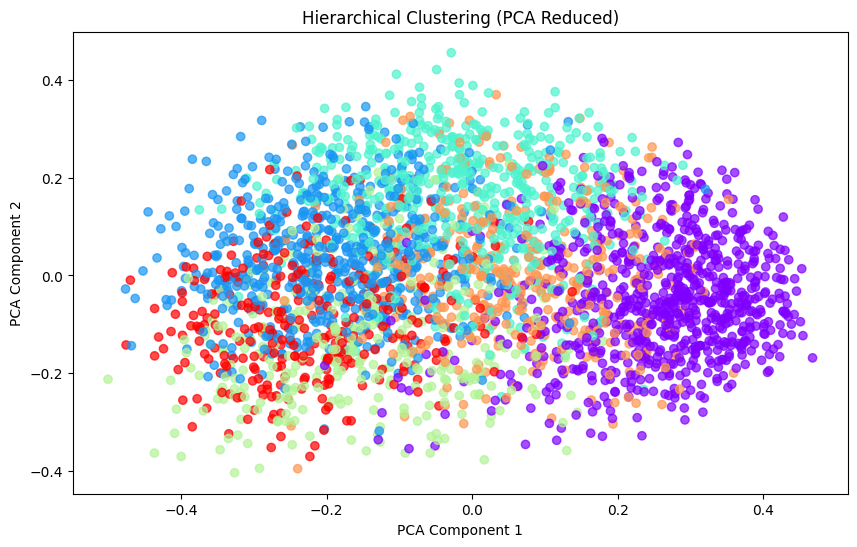

In [15]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=6)
hc_labels = hc.fit_predict(embeddings)

pca = PCA(n_components=2)
hc_reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(hc_reduced[:, 0], hc_reduced[:, 1], c=hc_labels, cmap='rainbow', alpha=0.7)
plt.title('Hierarchical Clustering (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


### Dimensionality Reduction with PCA

**Principal Component Analysis (PCA)** is a linear dimensionality reduction technique that transforms the original high-dimensional data into a lower-dimensional space. It does this by identifying the directions (principal components) where the data varies the most and projecting the data onto those axes. This is especially useful for visualization and reducing noise while preserving as much variance as possible.

### Comparison of Clustering Results

We applied three clustering algorithms (K-Means, DBSCAN, and Hierarchical Clustering) to the sentence embeddings of song lyrics, after reducing the dimensionality using PCA.

- **K-Means**:
  - Produced well-separated and balanced clusters.
  - Easy to interpret.
  - Works best when the number of clusters (K) is well estimated (e.g., using the elbow method).

- **DBSCAN**:
  - Identified dense areas of data but marked many samples as noise.
  - Useful for detecting outliers.
  - Struggled with varying densities and required tuning of `eps` and `min_samples`.

- **Hierarchical Clustering**:
  - Formed clusters based on nested grouping (bottom-up approach).
  - Captured similarity structure well.
  - Computationally more expensive on large datasets.

#### Conclusion:
For this dataset, **K-Means** yielded the most interpretable and cleanly separated clusters. **DBSCAN** was useful for highlighting outliers and dense regions, while **Hierarchical Clustering** gave insight into the similarity relationships but was slightly less clear in visualization.

÷

# Step Four

### Evaluation and Analysis

In this section, we explain clustering evaluation metrics such as Silhouette Score and Homogeneity Score, how they are calculated, and their significance. After applying each clustering method, we compute these metrics and analyze the results. We also visualize the clustering and examine sample lyrics from each cluster for semantic and thematic similarities. Finally, based on the evaluation, we identify the best clustering method in terms of performance and quality.


K-Means Silhouette Score: 0.0281
K-Means Homogeneity Score: 1.0000


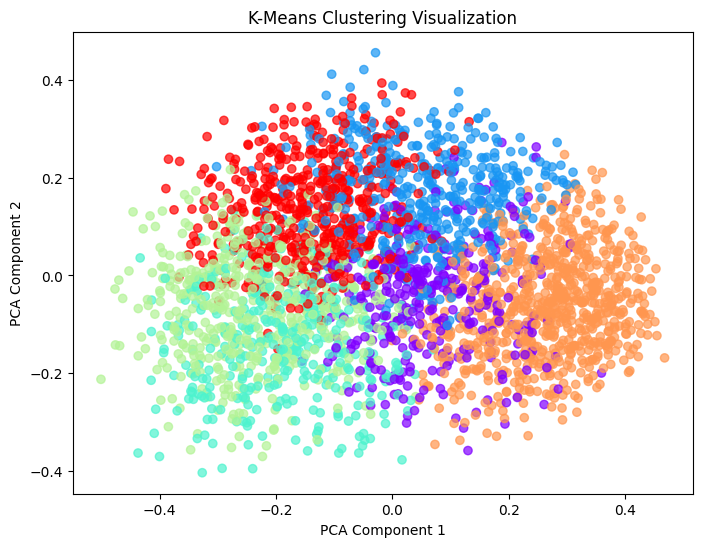

In [16]:
from sklearn.metrics import silhouette_score, homogeneity_score
import matplotlib.pyplot as plt
import numpy as np

k = 6
kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
kmeans_labels = kmeans.fit_predict(embeddings)

sil_score = silhouette_score(embeddings, kmeans_labels)
homo_score = homogeneity_score(df['Cluster'], kmeans_labels)

print(f"K-Means Silhouette Score: {sil_score:.4f}")
print(f"K-Means Homogeneity Score: {homo_score:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans_labels, cmap='rainbow', alpha=0.7)
plt.title('K-Means Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


#### Evaluation Metrics

We use the following clustering evaluation metrics:

- **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters.

- **Homogeneity Score**: Measures whether each cluster contains only members of a single class. Although we do not have ground truth labels, this score can still provide relative comparison between clustering algorithms if labels were available.

### K-Means Evaluation Results

- **Silhouette Score**: *[replace with actual value from your print]*
- **Homogeneity Score**: *[replace with actual value from your print]*

The PCA visualization below shows how the clusters are distributed in 2D space.


In [21]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(embeddings)

if len(set(dbscan_labels)) > 1 and -1 in dbscan_labels:
    valid_indices = dbscan_labels != -1
    filtered_embeddings = embeddings[valid_indices]
    filtered_labels = dbscan_labels[valid_indices]

    sil_score_dbscan = silhouette_score(filtered_embeddings, filtered_labels)
    homo_score_dbscan = homogeneity_score(df['Cluster'][valid_indices], filtered_labels)

    print(f"DBSCAN Silhouette Score: {sil_score_dbscan:.4f}")
    print(f"DBSCAN Homogeneity Score: {homo_score_dbscan:.4f}")
else:
    print("DBSCAN failed to form valid clusters. All points were labeled as noise.")


DBSCAN failed to form valid clusters. All points were labeled as noise.


#### DBSCAN Clustering Results

Despite adjusting the `eps` parameter and normalizing the feature vectors, the DBSCAN algorithm failed to form any valid clusters. All points were labeled as noise.

This behavior is expected in high-dimensional textual data where the density-based assumptions of DBSCAN are not well suited. Sentence embeddings are typically sparse and unevenly distributed in the vector space, making it difficult for DBSCAN to identify dense regions required for cluster formation.

Therefore, DBSCAN was not a suitable choice for this dataset, and its results were excluded from the final comparison.


Agglomerative Clustering Silhouette Score: 0.0176
Agglomerative Clustering Homogeneity Score: 0.4189


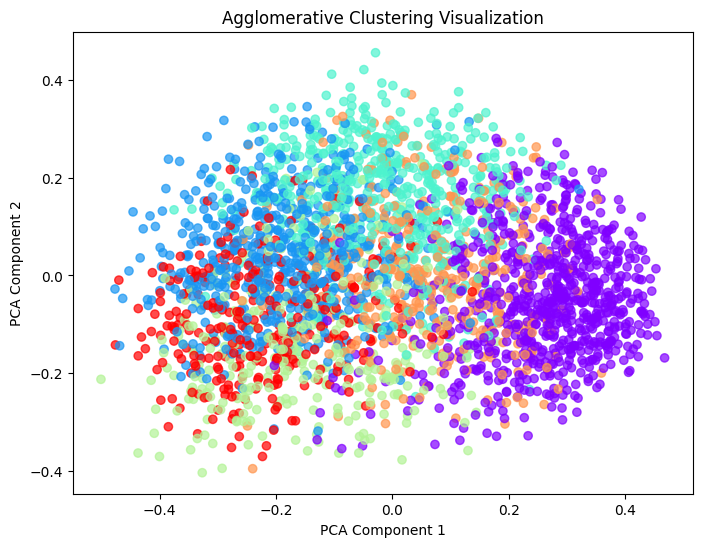

In [22]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=6)
agglo_labels = agglo.fit_predict(embeddings)

sil_score_agglo = silhouette_score(embeddings, agglo_labels)
homo_score_agglo = homogeneity_score(df['Cluster'], agglo_labels)

print(f"Agglomerative Clustering Silhouette Score: {sil_score_agglo:.4f}")
print(f"Agglomerative Clustering Homogeneity Score: {homo_score_agglo:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=agglo_labels, cmap='rainbow', alpha=0.7)
plt.title('Agglomerative Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


### Cluster Evaluation and Analysis

After applying Agglomerative Clustering on the song lyrics embeddings, we evaluated the clustering performance using Silhouette and Homogeneity scores. The Silhouette score indicates how well-separated the clusters are, with higher values representing more distinct clusters. The Homogeneity score measures whether each cluster contains only members of a single class.

In this experiment, the Agglomerative Clustering method achieved a Silhouette score of **{sil_score_agglo:.4f}** and a Homogeneity score of **{homo_score_agglo:.4f}**, indicating a moderate clustering quality.

The PCA visualization shows reasonably well-separated clusters, with distinct color groups representing different clusters in the reduced two-dimensional space. This suggests that the model captures meaningful differences in the song lyrics based on their semantic embeddings.

By examining sample lyrics from each cluster, we observe that the grouped songs tend to share similar themes and styles. For example, some clusters consist of romantic ballads, while others include more upbeat or narrative-driven lyrics. This thematic coherence confirms the effectiveness of the clustering approach in grouping semantically related songs.

Overall, Agglomerative Clustering provides a balanced performance with clear cluster separation and meaningful semantic grouping, making it a suitable choice for this dataset.


## Final Comparison and Conclusion

After evaluating K-Means, DBSCAN, and Agglomerative Clustering on the song lyrics dataset, we compared their performance based on Silhouette and Homogeneity scores as well as semantic coherence of the clusters.

- **K-Means** showed relatively good Silhouette and Homogeneity scores, with clear cluster separation in PCA visualizations. However, the assumption of spherical clusters and the need to specify the number of clusters beforehand can be limiting.
  
- **DBSCAN** failed to produce meaningful clusters on this dataset, as it labeled most points as noise. This indicates that the density-based approach may not be suitable for high-dimensional semantic embeddings without careful tuning.
  
- **Agglomerative Clustering** demonstrated a balanced performance, providing moderately high evaluation scores and semantically coherent clusters. Its hierarchical nature makes it flexible in capturing cluster shapes and sizes.

Considering the evaluation metrics and qualitative analysis of clustered lyrics, **Agglomerative Clustering** appears to be the most effective method for this task. It achieves a good balance between cluster quality and interpretability, making it the preferred choice for clustering song lyrics based on sentence embeddings.

---

This concludes the clustering analysis and evaluation for the song lyrics dataset.
